# Import thư viện và load data

In [1]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.features import process_location, select_model_features

# 1. Load dữ liệu sạch từ Phase 2
df_clean = pd.read_csv('../data/processed/housing_clean.csv')

# Thực thi Feature Engineering

In [2]:
# Trích xuất biến Vị trí (Province, District) và Khoảng cách đại diện tới Trung tâm CBD (Haversine Distance)
df_features = process_location(df_clean)
df_features = select_model_features(df_features)

# Bảng kiểm tra kiểm định khoảng cách một số Quận/Huyện tiêu biểu tới CBD (Hoàn Kiếm / Quận 1)
sample_districts = ['Hoàn Kiếm', 'Cầu Giấy', 'Hà Đông', 'Quận 1', 'Quận 7', 'Thủ Đức', 'Bình Chánh']
display(df_features[df_features['district'].isin(sample_districts)][['province', 'district', 'distance_to_center_km']].drop_duplicates())

,province,district,distance_to_center_km
1,Hồ Chí Minh,Bình Chánh,15.37
4,Hà Nội,Cầu Giấy,6.65
5,Hà Nội,Hà Đông,10.40
16,Hồ Chí Minh,Thủ Đức,9.91
59,Hồ Chí Minh,Quận 7,5.29
115,Hồ Chí Minh,Quận 1,0.15
363,Hà Nội,Hoàn Kiếm,0.00


# Kiểm tra kết quả

In [3]:
print(f"Kích thước bộ dữ liệu: {df_features.shape}")
print("\nDanh sách các cột đưa vào mô hình:")
print(df_features.columns.tolist())
display(df_features[['district', 'province', 'area_m2', 'bedrooms', 'frontage', 'distance_to_center_km', 'price_million_vnd']].head())

Kích thước bộ dữ liệu: (42201, 11)

Danh sách các cột đưa vào mô hình:
['area_m2', 'bedrooms', 'frontage', 'price_million_vnd', 'province', 'district', 'distance_to_center_km', 'log_area', 'area_sq', 'log_distance', 'area_dist_inter']


,district,province,area_m2,bedrooms,frontage,distance_to_center_km,price_million_vnd
0,Long Biên,Hà Nội,50.0,40.0,0,4.08,12500.0
1,Bình Chánh,Hồ Chí Minh,98.0,40.0,1,15.37,5500.0
2,Gò Vấp,Hồ Chí Minh,62.0,40.0,0,7.86,8740.0
3,Long Biên,Hà Nội,39.0,30.0,0,4.08,6500.0
4,Cầu Giấy,Hà Nội,45.0,30.0,1,6.65,16980.0


# Lưu dữ liệu

In [4]:
os.makedirs('../data/processed', exist_ok=True)
df_features.to_csv('../data/processed/housing_features.csv', index=False)
print('Đã lưu dữ liệu đặc trưng tại ../data/processed/housing_features.csv')

Đã lưu dữ liệu đặc trưng tại ../data/processed/housing_features.csv


# Trực quan hóa

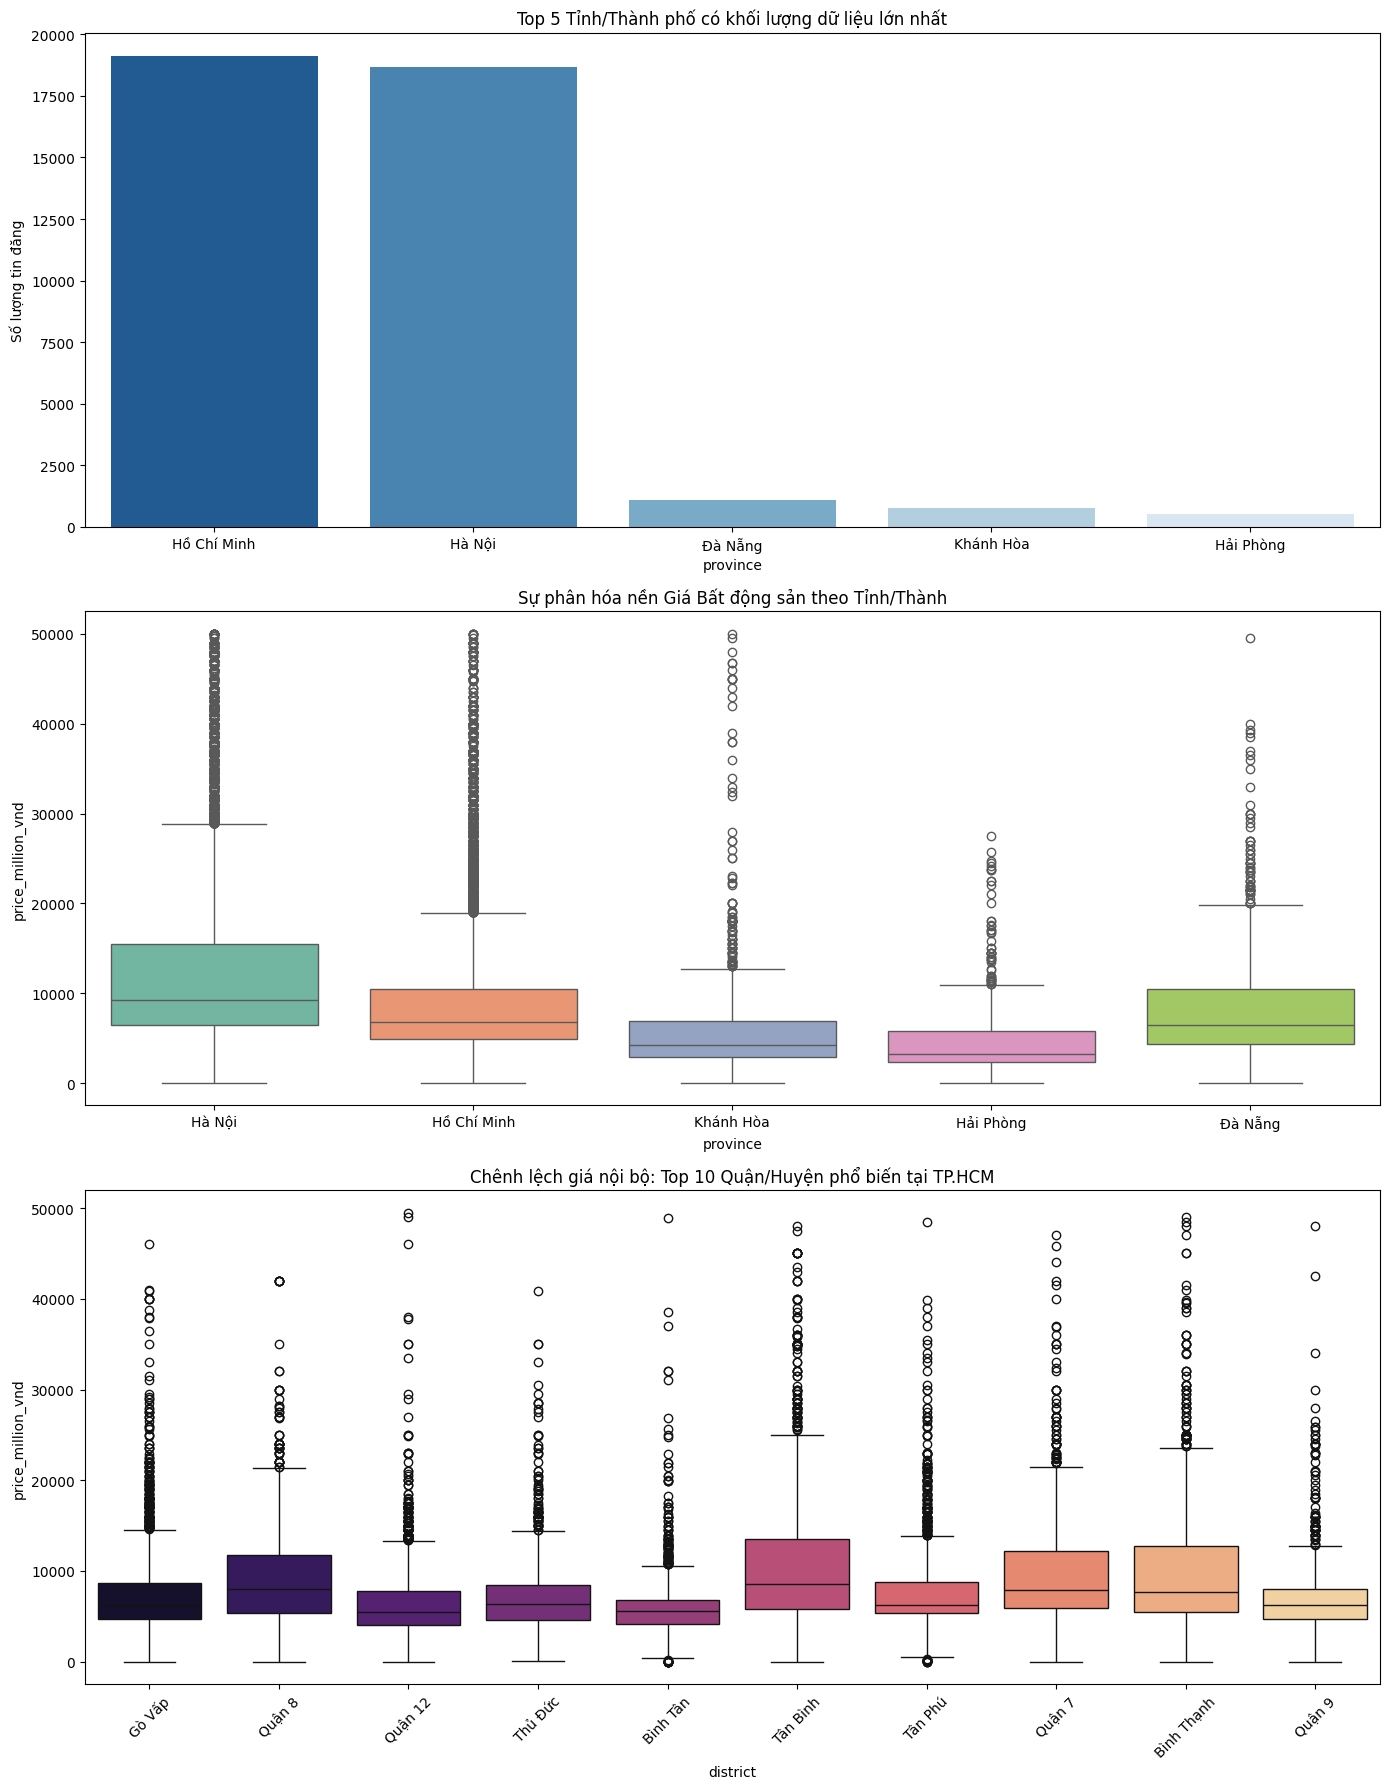

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# 1. Phân bố số lượng tin đăng theo Tỉnh/Thành
top_provinces = df_features['province'].value_counts().head(5)
sns.barplot(x=top_provinces.index, y=top_provinces.values, hue=top_provinces.index, palette='Blues_r', legend=False, ax=axes[0])
axes[0].set_title('Top 5 Tỉnh/Thành phố có khối lượng dữ liệu lớn nhất')
axes[0].set_ylabel('Số lượng tin đăng')

# 2. Mặt bằng giá giữa các Tỉnh/Thành
top_prov_df = df_features[df_features['province'].isin(top_provinces.index)]
sns.boxplot(data=top_prov_df, x='province', y='price_million_vnd', hue='province', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Sự phân hóa nền Giá Bất động sản theo Tỉnh/Thành')

# 3. Sự phân hóa Giá cấp Quận/Huyện (TP. Hồ Chí Minh)
hcm_data = df_features[df_features['province'] == 'Hồ Chí Minh']
top_hcm_districts = hcm_data['district'].value_counts().head(10).index
hcm_top_df = hcm_data[hcm_data['district'].isin(top_hcm_districts)]
sns.boxplot(data=hcm_top_df, x='district', y='price_million_vnd', hue='district', palette='magma', legend=False, ax=axes[2])
axes[2].set_title('Chênh lệch giá nội bộ: Top 10 Quận/Huyện phổ biến tại TP.HCM')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Độ lệch tâm của dữ liệu (Data Imbalance)**

*   Dữ liệu tập trung áp đảo tại TP.HCM (hơn 30.000 tin) và Hà Nội (hơn 20.000 tin), bỏ xa Đà Nẵng, Đồng Nai và Bình Dương. Thuật toán Linear Regression sẽ tối ưu trọng số rất tốt cho hai thị trường lõi này, nhưng phải chấp nhận rủi ro sai số (variance) cao hơn khi dự báo giá tại các tỉnh thành nhỏ do thiếu hụt dữ liệu học.


**Sự phân hóa nền giá vĩ mô (Cấp Tỉnh/Thành)**

*   Hộp phân vị (Boxplot) minh chứng mỗi địa phương có một mặt bằng giá độc lập. TP.HCM và Hà Nội sở hữu dải dữ liệu kéo rất dài với hàng loạt bất động sản siêu sang (True Outliers chạm mức 400.000 triệu VNĐ). Sự khác biệt cấu trúc này khẳng định việc trích xuất biến province là yếu tố bắt buộc để mô hình nhận diện được "hệ quy chiếu" giá trị của từng khu vực.


**Chênh lệch giá trị vi mô (Cấp Quận/Huyện)**

*   Ngay trong nội bộ TP.HCM, phân khúc giá biến động cực mạnh. Các khu vực như Quận 12, Gò Vấp hay Thủ Đức có chung vùng giá trị trung vị nhưng lại chênh lệch khổng lồ ở phần đuôi dữ liệu cao cấp. Điều này chứng minh đặc trưng district chính là biến đại diện (proxy) hoàn hảo nhất để đo lường sức nặng vị trí, thay thế thành công cho cột "Distance\_to\_Center" bị thiếu trong dataset gốc.